# Biomedical Data Science 2026: Homework Assignment 3
### CBB & CPSC & S&DS (programming) Assignment

Due: April 30th 11:59pm EST

#### Name:  Lynn Karam

### Dependencies

#### If your are using Google Colab
Run the following cell before running the notebook.
To run the public tests (the `grader.check()` cells) in this notebook, you need to run the following cell first to get tests.zip.

In [ ]:
# For Colab users only.
import sys
if 'google.colab' in sys.modules:
  !{sys.executable} -m pip install -q otter-grader py3Dmol biopython requests
  !wget -q https://files.gersteinlab.org/public-docs/2026/04.03/tests.zip
  !unzip -q tests.zip
  print("Colab setup complete: tests downloaded.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.5/142.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 12.5 MB/s eta 0:00:00
Colab setup complete: tests downloaded.


In [ ]:
import json
from google.colab import _message

# Get notebook data
nb_data = _message.blocking_request('get_ipynb')['ipynb']

# Remove problematic widget metadata
if "widgets" in nb_data.get("metadata", {}):
    del nb_data["metadata"]["widgets"]

# Save cleaned notebook
with open("HW3_clean.ipynb", "w", encoding="utf-8") as f:
    json.dump(nb_data, f, indent=1)

print("Clean notebook saved as HW3_clean.ipynb")

#### If you are running this notebook locally
* Step 1: create and activate a virtual environemnt
    - Option 1: conda environment:
        ```
        conda create -y -n cbb7520 python=3.9
        conda activate cbb7520
        ```

    - Option 2: standard python virtual environment
        ```
        python3 -m venv cbb7520
        source cbb7520/bin/activate
        ```

* Step 2: install the dependencies
    ```
    pip install -r requirements.txt
    ```

To run the public tests (the `grader.check()` cells) in this notebook, make sure the `tests` folder and your notebook are in the same directory.

## Instructions

* You only need to write code between the `### START CODE HERE ###` and `### END CODE HERE ###` comments.
* You may write code outside of these blocks, but it will not be graded.
* If you make use of any online resource please cite the source in the code comments.
* Directly copying large chunks of code (even with variable name replacement) is not allowed and will be considered plagiarism.
* After writing your code, run the cell with **SHIFT+ENTER**.
* **Auto-grading:** Run `grader.check("q#")` after each question to see your score on the public tests.
* **Canvas submission:** Upload the completed `HW3_2026.ipynb` to Canvas.

### Setup

In [ ]:
import numpy as np
import requests
import matplotlib.pyplot as plt
import otter
grader = otter.Notebook()

---
## Part 1: Calculating dihedral angles of proteins

In [ ]:
# Part 1 data
core_THR_residues_URL = 'http://files2.gersteinlab.org/public-docs/2021/04.28/core_THR_residues.txt'
core_THR_residues = np.loadtxt(
    requests.get(core_THR_residues_URL).text.splitlines(), dtype=str
)
np.set_printoptions(threshold=40)
print('Loaded', core_THR_residues.shape[0], 'atom records for Part 1.')

Loaded 20000 atom records for Part 1.


In [ ]:
# Compute the dihedral angle (degrees) defined by four 3-D points
# Reference: https://student.cs.uwaterloo.ca/~cs483/CourseNotes/04_Protein_Geometry_H.pdf
def angles(u1, u2, u3, u4):
    a1 = -1.0 * (u2 - u1)
    a2 =        (u3 - u2)
    a3 =        (u4 - u3)
    a2 /= np.sqrt((a2 * a2).sum())
    v = a1 - np.dot(a1, a2) * a2
    w = a3 - np.dot(a3, a2) * a2
    return np.degrees(np.arctan2(np.dot(np.cross(a2, v), w), np.dot(v, w)))

## 1.1 (15 pts)
Ramachandran plots allow us to investigate the sterically allowed and disallowed backbone
dihedral angle combinations φ and ψ in proteins. Using the file `core_THR_residues.txt` provided,
produce a Ramachandran plot for threonine residues. The file contains atomic coordinates for
1000 threonine dipeptides. The Cα, carboxyl carbon, and oxygen atoms on the **prior** amino acid
are labelled `pCa`, `pC`, and `pO`. The N, Cα and H atoms on the **subsequent** amino acid are
labeled `nN`, `nCa`, and `nH`. Using this file and the predefined `angles` function, calculate φ and ψ for each residue and produce a
Ramachandran scatter plot. See the lecture notes for definitions of φ and ψ.

In [ ]:
def calculate_backbone_dihedrals(data):
    ### START CODE HERE ###
    atoms_per_residue = 20
    n_residues = len(data) // atoms_per_residue  # 20000 / 20 = 1000
    phi = np.zeros(n_residues)
    psi = np.zeros(n_residues)
    for i in range(n_residues):
        start = i * atoms_per_residue
        block = data[start : start + atoms_per_residue]

        # column format from the given file is [0]=residue_id, [1]=atom_name, [2]=x, [3]=y, [4]=z
        atom_dict = {}
        for row in block:
            label = row[1]
            xyz = row[2:5].astype(float)
            atom_dict[label] = xyz

        # phi is pC - N - CA - C
        phi[i] = angles(atom_dict['pC'], atom_dict['N'], atom_dict['CA'], atom_dict['C'])
        # psi is N - CA - C - nN
        psi[i] = angles(atom_dict['N'], atom_dict['CA'], atom_dict['C'], atom_dict['nN'])

    ### END CODE HERE ###
    return phi, psi

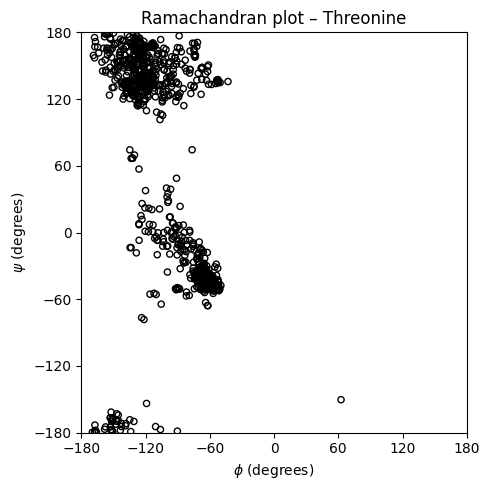

In [ ]:
phi, psi = calculate_backbone_dihedrals(core_THR_residues)

plt.figure(figsize=(5, 5))
plt.xticks(np.arange(-180, 181, 60))
plt.yticks(np.arange(-180, 181, 60))
plt.xlabel(r'$\phi$ (degrees)')
plt.ylabel(r'$\psi$ (degrees)')
plt.xlim([-180, 180]); plt.ylim([-180, 180])
plt.scatter(phi, psi, s=20, facecolors='none', edgecolors='k')
plt.title('Ramachandran plot – Threonine')
plt.tight_layout()
plt.show()

In [ ]:
grader.check("q1.1")

q1.1 results: All test cases passed!

## 1.2 (15 pts)
In the lecture notes we discussed sidechain dihedral angles. Threonine has exactly one,
χ1. Using `core_THR_residues.txt`, generate the observed χ1 distribution for the 1000
threonine dipeptides and plot it as a density histogram.
See the lecture notes for the definition of χ1 in threonine.

> **Hint:** The four atoms that define χ1 in threonine are **N – Cα – Cβ – OG1**.  
> After computing the raw dihedral, remap any negative values into [0°, 360°] by adding 360.

In [ ]:
def calculate_threonine_dihedrals(data):
    ### START CODE HERE ###
    # first part of my code is the same as what I used for 1.1
    atoms_per_residue = 20
    n_residues = len(data) // atoms_per_residue
    chi = np.zeros(n_residues)
    for i in range(n_residues):
        start = i * atoms_per_residue
        block = data[start : start + atoms_per_residue]
        atom_dict = {}
        for row in block:
            label = row[1]
            xyz = row[2:5].astype(float)
            atom_dict[label] = xyz

        # the 4 atoms that define chi1 (χ1) are  N - CA - CB - OG1
        raw_angle = angles(atom_dict['N'], atom_dict['CA'], atom_dict['CB'], atom_dict['OG1'])
        # remap the negative values from [-180, 180] to [0, 360]
        if raw_angle < 0:
            raw_angle += 360
        chi[i] = raw_angle

    ### END CODE HERE ###
    return chi

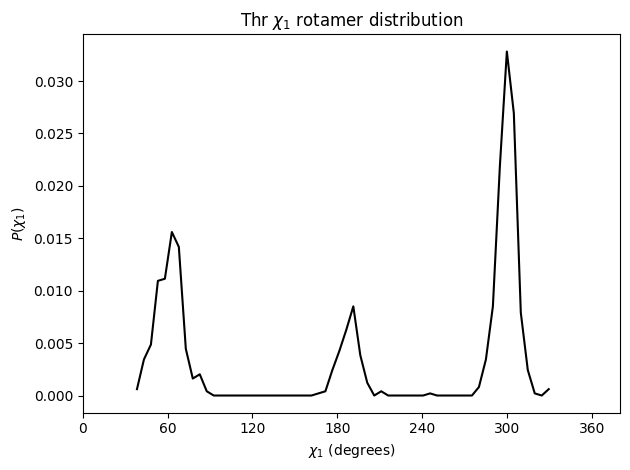

In [ ]:
chi = calculate_threonine_dihedrals(core_THR_residues)

values, binedges = np.histogram(chi, bins=60, density=True)
x = 0.5 * (binedges[:-1] + binedges[1:])
plt.xticks(np.arange(0, 361, 60))
plt.xlabel(r'$\chi_1$ (degrees)')
plt.ylabel(r'$P(\chi_1)$')
plt.xlim([0, 380])
plt.plot(x, values, 'k')
plt.title(r'Thr $\chi_1$ rotamer distribution')
plt.tight_layout()
plt.show()

In [ ]:
grader.check("q1.2")

q1.2 results: All test cases passed!

---
## Part 2: Protein Structure Prediction and Comparison

**Background**

[AlphaFold](https://alphafold.ebi.ac.uk/) is a deep-learning system from Google DeepMind that predicts
a protein's 3-D structure from its amino acid sequence.

In this part you will:
1. **Fetch** the AlphaFold-predicted structure and the experimental crystal structure for
   **green fluorescent protein (GFP)** (UniProt `Q9GPI6`, PDB `2C9I`) directly from public databases.
2. **Visualise** both structures interactively in the notebook with [py3Dmol](https://pypi.org/project/py3Dmol/),
   colouring the AlphaFold model by prediction confidence (pLDDT).
3. **Quantify** the structural similarity by computing the Cα RMSD between the two structures using Biopython.

> **No GPU needed.** All computation runs on CPU — both locally and on Google Colab (free tier).

### Key concepts

| Term | Meaning |
|------|---------|
| **pLDDT** | Per-residue confidence score (0–100). >90 = very high, 70–90 = confident, 50–70 = low, <50 = very low |
| **Cα RMSD** | Root-mean-square deviation of alpha-carbon positions after superimposition (Å). <1 Å = excellent agreement |
| **Superimposition** | Rigid-body rotation + translation that minimises RMSD between two coordinate sets |

### Installation

**Local Jupyter:** run the cell below once.  
**Google Colab:** the same cell works — Colab already has Biopython, but py3Dmol needs installing.

In [ ]:
# Version check
import py3Dmol, Bio
print(f"py3Dmol {py3Dmol.__version__}  |  Biopython {Bio.__version__}")

py3Dmol 2.5.4  |  Biopython 1.87


### Fetching the structures

The cell below downloads:
- The **AlphaFold prediction** for GFP from the EMBL-EBI AlphaFold Database API.
- The **experimental structure** (2C9I, chain A) from the RCSB PDB.

Both are stored as plain PDB-format strings — ready for Biopython and py3Dmol.
You do **not** need to modify this cell.

In [ ]:
UNIPROT_ID  = "Q9GPI6"   # Green fluorescent protein (GFP)
PDB_ID      = "2C9I"     # X-ray crystal structure, 1.82 Å resolution

# AlphaFold DB: fetch the PDB URL via the REST API, then download the file
af_api_url = f"https://alphafold.ebi.ac.uk/api/prediction/{UNIPROT_ID}"
af_meta    = requests.get(af_api_url, timeout=30).json()
af_pdb_url = af_meta[0]["pdbUrl"]
AF_PDB_STR = requests.get(af_pdb_url, timeout=60).text
print(f"AlphaFold structure: {af_meta[0]['entryId']}  "
      f"({AF_PDB_STR.count('ATOM')} ATOM records)")

# RCSB PDB: fetch the full crystal structure, then extract chain A as PDB string
rcsb_url  = f"https://files.rcsb.org/download/{PDB_ID}.pdb"
cr_pdb_full = requests.get(rcsb_url, timeout=30).text

# Filter ATOM records
cr_lines = []
for line in cr_pdb_full.splitlines():
    if line.startswith(('HEADER', 'TITLE', 'REMARK', 'ATOM')):
        if line.startswith('ATOM'):
            if line[21] == 'A':  # Chain A only
                cr_lines.append(line)
        else:
            cr_lines.append(line)
    elif line.startswith('END'):
        cr_lines.append(line)
        break

CR_PDB_STR = '\n'.join(cr_lines)
print(f"Crystal structure : {PDB_ID}  "
      f"({CR_PDB_STR.count('ATOM')} ATOM records)")

AlphaFold structure: AF-Q9GPI6-F1  (1783 ATOM records)
Crystal structure : 2C9I  (1786 ATOM records)


## 2.1 (15 pts) — Visualising Protein Structures with py3Dmol

Complete and implement the function `visualize_structures(af_pdb_str, cr_pdb_str)` that displays the
AlphaFold-predicted and crystal structures **side by side** in a single interactive 3-D viewer.

**Requirements:**
- Use `py3Dmol.view(width=800, height=400)` with `linked=False` to create a two-panel viewer.
- Load each PDB string with `view.addModel(pdb_str, 'pdb', viewer)`, set the style with `view.setStyle({'model': 0}, style_dict)`.
- **Left panel:** AlphaFold structure, cartoon style, coloured by pLDDT.
  Use `{'cartoon': {'colorscheme': {'prop': 'b', 'gradient': 'roygb', 'min': 50, 'max': 100}}}` for style.
- **Right panel:** Crystal structure (GFP 2C9I chain A), cartoon style, solid green. Use `{'cartoon': {'color': 'green'}` for style.
- Call `view.zoomTo()` and `view.show()` at the end.
- The function should **return** the `view` object.

In [ ]:
def visualize_structures(af_pdb_str, cr_pdb_str):
    ### START CODE HERE ###
    # create a two-panel viewer
    view = py3Dmol.view(width=800, height=400, linked=False, viewergrid=(1, 2))
    # Left panel: AlphaFold structure, cartoon style, coloured by pLDDT
    view.addModel(af_pdb_str, 'pdb', viewer=(0, 0))
    view.setStyle({'model': 0},{'cartoon': {'colorscheme': {'prop': 'b', 'gradient': 'roygb', 'min': 50, 'max': 100}}},viewer=(0, 0))
    # Right panel: Crystal structure (GFP 2C9I chain A), cartoon style, solid green.
    view.addModel(cr_pdb_str, 'pdb', viewer=(0, 1))
    view.setStyle({'model': 0},{'cartoon': {'color': 'green'}},viewer=(0, 1))
    view.zoomTo()
    view.show()

    ### END CODE HERE ###
    return view


# Run visualization
view = visualize_structures(AF_PDB_STR, CR_PDB_STR)
print("Left panel : AlphaFold prediction for GFP (coloured by pLDDT confidence)")
print("Right panel: GFP crystal structure 2C9I chain A (green)")
print("\nColour key (AlphaFold panel):")
print("  Blue   → pLDDT ≥ 90  (very high confidence)")
print("  Cyan   → pLDDT 70–90 (confident)")
print("  Yellow → pLDDT 50–70 (low confidence)")
print("  Red    → pLDDT < 50  (very low confidence)")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Left panel : AlphaFold prediction for GFP (coloured by pLDDT confidence)
Right panel: GFP crystal structure 2C9I chain A (green)

Colour key (AlphaFold panel):
  Blue   → pLDDT ≥ 90  (very high confidence)
  Cyan   → pLDDT 70–90 (confident)
  Yellow → pLDDT 50–70 (low confidence)
  Red    → pLDDT < 50  (very low confidence)


In [ ]:
grader.check("q2.1")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

q2.1 results: All test cases passed!

## 2.2 (15 pts) — Computing Cα RMSD Between Predicted and Experimental Structures

Implement `compute_ca_rmsd(af_pdb_str, cr_pdb_str)` that:

1. **Parses** both PDB strings into Biopython `Structure` objects using `PDBParser`.
2. **Extracts** all Cα atoms from the first chain of each structure in residue-number order.
3. **Align** the two chains so the atom lists are the same length using `PairwiseAligner`.
4. **Superimposes** the AlphaFold Cα atoms onto the crystal structure Cα atoms using `Superimposer`.
5. **Returns** the RMSD (in Å) as a Python `float`.

> **Hints:**
> - `PDBParser(QUIET=True).get_structure("name", io.StringIO(pdb_str))` parses a string.
> - `Bio.PDB.Superimposer` usage:
>   ```python
>   sup = Superimposer()
>   sup.set_atoms(fixed_atoms, moving_atoms)   # fixed=CR, moving=AF
>   sup.apply(moving_structure.get_atoms())
>   rmsd = sup.rms
>   ```

In [ ]:
import io
from Bio.PDB import PDBParser, Superimposer
from Bio.SeqUtils import seq1
from Bio.Align import PairwiseAligner

def compute_ca_rmsd(af_pdb_str, cr_pdb_str):
    ### START CODE HERE ###

    # 1. Parses both PDB strings into Biopython Structure objects using PDBParser.
    # Reference: https://biopython.org/wiki/PDBParser
    parser = PDBParser(QUIET=True)
    af_struct = parser.get_structure("af", io.StringIO(af_pdb_str))
    cr_struct = parser.get_structure("cr", io.StringIO(cr_pdb_str))

    # 2. Extracts all Cα atoms from the first chain of each structure in residue-number order.
    af_residues = sorted([r for r in list(af_struct.get_chains())[0].get_residues() if 'CA' in r], key=lambda r: r.id[1])
    cr_residues = sorted([r for r in list(cr_struct.get_chains())[0].get_residues() if 'CA' in r], key=lambda r: r.id[1])
    af_seq = "".join([seq1(r.get_resname()) for r in af_residues])
    cr_seq = "".join([seq1(r.get_resname()) for r in cr_residues])

    # 3. Align the two sequences to find matching residue positions
    # Reference: https://biopython.org/docs/dev/Tutorial/chapter_pairwise.html
    aligner = PairwiseAligner()
    aligner.mode = 'global'
    aligner.open_gap_score = -10
    aligner.extend_gap_score = -0.5
    alignment = aligner.align(af_seq, cr_seq)[0]

    # 4. Collect only matched (non-gap) Cα atom pairs
    af_matched, cr_matched = [], []
    af_idx, cr_idx = 0, 0
    for a, b in zip(alignment[0], alignment[1]):
        if a != '-' and b != '-':
            af_matched.append(af_residues[af_idx]['CA'])
            cr_matched.append(cr_residues[cr_idx]['CA'])
        if a != '-':
            af_idx += 1
        if b != '-':
            cr_idx += 1

    # 5. Superimposes the AlphaFold Cα atoms and compute RMSD
    # from hint
    sup = Superimposer()
    sup.set_atoms(cr_matched, af_matched)   # fixed=CR, moving=AF
    sup.apply(af_struct.get_atoms())

    ### END CODE HERE ###
    return float(sup.rms)


# Run it and interpret the result
ca_rmsd = compute_ca_rmsd(AF_PDB_STR, CR_PDB_STR)
print(f"Cα RMSD (AlphaFold vs crystal structure 2C9I chain A): {ca_rmsd:.3f} Å")

if ca_rmsd < 0.5:
    print("Interpretation: Excellent — AlphaFold closely matches the crystal structure.")
elif ca_rmsd < 1.5:
    print("Interpretation: Very good agreement — minor structural differences.")
elif ca_rmsd < 3.0:
    print("Interpretation: Moderate agreement — some notable differences.")
else:
    print("Interpretation: Large deviation — check the alignment or structure quality.")

Cα RMSD (AlphaFold vs crystal structure 2C9I chain A): 0.267 Å
Interpretation: Excellent — AlphaFold closely matches the crystal structure.


In [ ]:
grader.check("q2.2")

q2.2 results: All test cases passed!

---
## Part 3 — PCA of ESM-2 Embeddings by Functional Family

**Background:** ESM-2 is a representation learning model trained with a masked language modelling objective on hundreds of millions of protein sequences from UniRef50. Like BERT for text, it learns contextual representations of amino acids by predicting randomly masked positions. The resulting embeddings capture rich information about protein structure and function — purely from sequence, with no structural supervision.

We will use **ESM-2 (35M)** hosted on HuggingFace. We mean-pool across all residues to get a single sequence-level representation,
then project with PCA onto 2 dimensions.

> Reference: Lin et al. (2023) *Evolutionary-scale prediction of atomic-level protein structure with a language model.* Science.

### Setup

In [ ]:
import torch
from sklearn.decomposition import PCA
from transformers import AutoTokenizer, AutoModel

### Loading ESM-2

In [ ]:
# Load the ESM-2 35M model and tokenizer
MODEL = "facebook/esm2_t12_35M_UR50D"
print(f"\nLoading {MODEL} …")
tokenizer_35m = AutoTokenizer.from_pretrained(MODEL)
model_35m = AutoModel.from_pretrained(MODEL).eval()
model_35m.config._attn_implementation = "eager"
cfg2 = model_35m.config
print(f"  Layers: {cfg2.num_hidden_layers}  |  Heads: {cfg2.num_attention_heads}  |  Dim: {cfg2.hidden_size}")


Loading facebook/esm2_t12_35M_UR50D …


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/778 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/136M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/209 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Layers: 12  |  Heads: 20  |  Dim: 480


### Loading Protein Sequences

We use **16 proteins from four functional families** (4 per family).

| Family | Description | Members |
|---|---|---|
| **Globin** | α-helical heme-containing oxygen carriers | Myoglobin, Hb-α, Hb-β, Neuroglobin |
| **Immunoglobulin** | β-sandwich immune/adhesion domains | IgG1-CH1, Tenascin-FN3, CD4-D1, CTLA4-D1 |
| **Kinase** | α/β ATP-binding phosphotransferases | PKA, CDK2, ERK2, MAPK |
| **Protease** | serine proteases (chymotrypsin fold) | Trypsin, Chymotrypsin, Elastase, Subtilisin |

In [ ]:
PROTEINS = [
    # (name, family, sequence)

    # GLOBINS
    ("Myoglobin",    "Globin",
     "MGLSDGEWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLEKFDKFKHLKSEDEMKASEDLKKHGAT"),
    ("Hemoglobin_a", "Globin",
     "MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDLHAHKLR"),
    ("Hemoglobin_b", "Globin",
     "MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLD"),
    ("Neuroglobin",  "Globin",
     "MERPEPELIRQSWRAVSRSPLEHGTVLARLFDYPDMKNYHPIDGQYTVLESLRQQINDLVSRNFPRYFHHFGQDLSTPDLQRLAEFLASLT"),

    # IMMUNOGLOBULINS
    ("IgG1_CH1",     "Immunoglobulin",
     "ASTKGPSVFPLAPSSKSTSGGTAALGCLVKDYFPEPVTVSWNSGALTSGVHTFPAVLQSSGLYSLSSVVTVPSSSLGTQTYICNVNHKPSNTK"),
    ("Tenascin_FN3", "Immunoglobulin",
     "APFEGGYVHFGNPQGFQYTDAATKTFPGIFLQDNPQNISRGAQYVKFPKGKKLDMPKNPDLHFEHISIFPHFTHQY"),
    ("CD4_D1",       "Immunoglobulin",
     "MNRGVPFRHLLLVLQLALLPAATQGKKVVLGKKGDTVELTCTASQKKSIQFHWKNSNQIKILGNQGSFLTKGPSKLNDRADSRRSLWDQGNFP"),
    ("CTLA4_D1",     "Immunoglobulin",
     "HYVNMHQALSTASTFEPTHLPTVEEGAAHTLRCALPDSEEDSACQRWGQHFPLQEVPEDLLFQAFYEIMRRERQRGDSYQQLSAYLNLSSGQL"),

    # PROTEIN KINASES
    ("PKA_cat",      "Kinase",
     "GNAAAAKKGSEQESVKEFLAKAKEDFLKKWENPAQNTAHLDQFERIKTLGTGSFGRVMLVKHKETGNHYAMKILDKQKVVKLKQIEH"),
    ("CDK2_N",       "Kinase",
     "MENFQKVEKIGEGTYGVVYKARNKLTGEVVALKKIRLDTETEGVPSTAIREISLLKELNHPNIVKLLDVIHTENKLYLVFEFLHQDLKKFMD"),
    ("ERK2_N",       "Kinase",
     "MAAAAAAGAGPEMVRGQVFDVGPRYTNLSYIGEGAYGMVCSAYDNLNKVRVAIKKISPFEHQTYCQRTLREIKILLRFRHENIIGINDIIRA"),
    ("p38_MAPK_N",   "Kinase",
     "MSQERPTFYRQELNKTIWEVPERYQNLSPVGSGAYGSVCAAFDTKTGLRVAVKKLSRPFQSIIHAKRTYRELRLLKHMKHENVIGLLDVFTP"),

    # SERINE PROTEASES
    ("Trypsin",      "Protease",
     "IVGGYTCGANTVPYQVSLNSGYHFCGGSLINSQWVVSAAHCYKSGIQVRLGEDNINVVEGNEQFISASKSIVHPSYNSNTLNN"),
    ("Chymotrypsin", "Protease",
     "CGVPAIQPVLSGLSRIVNGEEAVPGSWPWQVSLQDKTGFHFCGGSLINENWVVTAAHCGVTTSDVVVAGEFDQGSSSEKI"),
    ("Elastase",     "Protease",
     "VVGGTEAQRNSWPSQISLQYRSGSSWAHTCGGTLIRQNWVMTAAHCVDRELTFRVVVGEHNLNQNNGTEQYVGVQKIVV"),
    ("Subtilisin",   "Protease",
     "AQSVPWGISRVQAPAAHNRGLTGSGVKVAVLDTGISTHPDLNIRGGASFVPGEPSTQDGNGHGTHVAGTIAALNNSIGVLGVAPSAELY"),
]

NAMES   = [p[0] for p in PROTEINS]
CLASSES = [p[1] for p in PROTEINS]
SEQS    = [p[2] for p in PROTEINS]

FAMILY_COLORS  = {"Globin": "#E63946", "Immunoglobulin": "#2196F3",
                  "Kinase": "#4CAF50",  "Protease": "#FF9800"}
FAMILY_MARKERS = {"Globin": "o", "Immunoglobulin": "s",
                  "Kinase": "^", "Protease": "D"}

print(f"{len(PROTEINS)} proteins across {len(set(CLASSES))} families.")
for fam in sorted(set(CLASSES)):
    members = [n for n,c,_ in PROTEINS if c==fam]
    print(f"  {fam:16s}: {', '.join(members)}")

16 proteins across 4 families.
  Globin          : Myoglobin, Hemoglobin_a, Hemoglobin_b, Neuroglobin
  Immunoglobulin  : IgG1_CH1, Tenascin_FN3, CD4_D1, CTLA4_D1
  Kinase          : PKA_cat, CDK2_N, ERK2_N, p38_MAPK_N
  Protease        : Trypsin, Chymotrypsin, Elastase, Subtilisin


## 3.1 (15 pts) Compute mean-pooled embeddings

Implement `get_mean_embedding(sequence, model, tokenizer, layer_idx=9)` that:

1. Tokenises `sequence` and runs a forward pass with `output_hidden_states=True`.
2. Retrieves the hidden states for `layer_idx` from `outputs.hidden_states`
   (a tuple where index 0 = embedding layer, index k = output of transformer layer k).
3. **Excludes the first and last tokens** (`<cls>` / `<eos>`) and averages
   the remaining L positions.
4. Returns a 1-D NumPy array of shape **(hidden_dim,)**.

> **Layer choice matters.** ESM-2's *last* layer is optimised for predicting masked
> amino acids. *Intermediate* layers (around 75% through the network) tend to encode
> more transferable structural and functional features — analogous to how BERT's
> middle layers are used for downstream NLP tasks. For ESM-2 35M (12 layers) we
> default to **layer 9** (`layer_idx=9`), which gives cleaner family-level clustering.

In [ ]:
def get_mean_embedding(sequence, model, tokenizer, layer_idx=9):
    ### START CODE HERE ###

    # 1. Tokenize the sequence (converts amino acid letters to token ids that the model understands)
    inputs = tokenizer(sequence, return_tensors='pt')   # return_tensors='pt' returns PyTorch tensors instead of plain Python lists

    # 2. Run the sequence through the model
    # torch.no_grad() disables gradient tracking since we're only doing inference, not training
    # Reference: https://docs.pytorch.org/docs/stable/generated/torch.no_grad.html
    # Reference: https://www.geeksforgeeks.org/python/what-is-with-torch-no_grad-in-pytorch/
    # Reference: https://docs.python.org/3/tutorial/controlflow.html#unpacking-argument-lists
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    # 3. Get the hidden states at the chosen layer
    # hidden_states is a tuple with index 0 = embedding layer, index k = output of transformer layer k
    hidden = outputs.hidden_states[layer_idx]

    # 4. Excludes the first and last tokens (<cls> / <eos>) and averages the remaining L positions
    embedding = hidden[0, 1:-1, :].mean(dim=0).numpy()

    ### END CODE HERE ###
    return embedding

layer_idx = 9
_emb_test = get_mean_embedding(SEQS[0], model_35m, tokenizer_35m, layer_idx)
print(f"Embedding shape  : {_emb_test.shape}  (expected: ({model_35m.config.hidden_size},))")
print(f"Layer used       : {layer_idx} of {model_35m.config.num_hidden_layers}")
print(f"Mean, Std       : {_emb_test.mean():.4f}, {_emb_test.std():.4f}")

Embedding shape  : (480,)  (expected: (480,))
Layer used       : 9 of 12
Mean, Std       : -0.1358, 3.0292


In [ ]:
grader.check("q3.1")

q3.1 results: All test cases passed!

## 3.2 (15 pts) Compute all embeddings and run PCA

Implement `plot_embedding_pca(seqs, names, families, model, tokenizer)` that:

1. Calls `get_mean_embedding` for each sequence and stacks results into
   an (N, hidden_dim) matrix.
2. Runs `PCA(n_components=2)` and projects to (N, 2).
3. Creates a scatter plot:
   - Points coloured by family (use `FAMILY_COLORS`) and shaped by family
     (use `FAMILY_MARKERS`), with `s=120`.
   - Each point annotated with the protein name.
   - Axis labels show variance explained: `"PC1 (XX.X% variance)"`.
   - Legend identifying the four families.
4. Returns `(fig, pca, embeddings_2d)`.

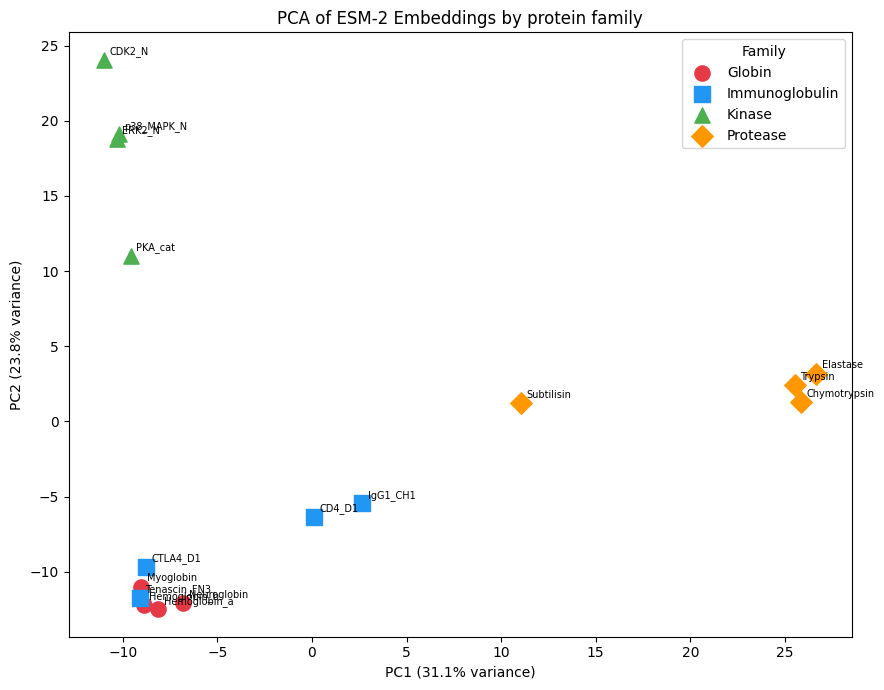

PC1+PC2 variance explained: 54.9%


In [ ]:
def plot_embedding_pca(seqs, names, families, model, tokenizer):
    ### START CODE HERE ###

    # 1. Get embedding for every sequence and stack into a matrix
    # Reference: https://numpy.org/doc/stable/reference/generated/numpy.array.html
    all_embeddings = []
    for seq in seqs:
        emb = get_mean_embedding(seq, model, tokenizer)
        all_embeddings.append(emb)
    embedding_matrix = np.array(all_embeddings)

    # 2. Run PCA to reduce from hidden_dim dimensions down to 2
    # Reference: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embedding_matrix)

    # 3. Plot each family with its own color and marker shape
    fig, ax = plt.subplots(figsize=(9, 7))
    for family in sorted(set(families)):
        idx = [i for i, f in enumerate(families) if f == family]
        ax.scatter(embeddings_2d[idx, 0], embeddings_2d[idx, 1], c=FAMILY_COLORS[family], marker=FAMILY_MARKERS[family], s=120, label=family)

    # 4. Label each point with the protein name
    # Reference: https://stackoverflow.com/questions/60786421/how-do-you-offset-text-in-a-scatter-plot-in-matplotlib
    for i, name in enumerate(names):
        ax.annotate(name, (embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=7, xytext=(4, 4), textcoords='offset points')

    # 5. Add axis labels showing how much variance each PC explains, and a legend
    var1 = pca.explained_variance_ratio_[0] * 100
    var2 = pca.explained_variance_ratio_[1] * 100
    ax.set_xlabel(f"PC1 ({var1:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({var2:.1f}% variance)")
    ax.set_title("PCA of ESM-2 Embeddings by protein family")
    ax.legend(title="Family")
    plt.tight_layout()

    ### END CODE HERE ###
    return fig, pca, embeddings_2d


fig_pca, pca_obj, embs_2d = plot_embedding_pca(
    SEQS, NAMES, CLASSES, model_35m, tokenizer_35m
)
plt.show()
var_total = pca_obj.explained_variance_ratio_[:2].sum() * 100
print(f"PC1+PC2 variance explained: {var_total:.1f}%")

In [ ]:
grader.check("q3.2")

q3.2 results: All test cases passed!

## 3.3 (10 pts) Written interpretation

<!-- BEGIN QUESTION -->

1. (5 pts) **Do proteins from the same functional family cluster together?** Describe what you see for each of the four families (Globin, Immunoglobulin, Kinase, Protease). Which is tightest? Which is most spread out?

2. (5 pts) PC1 and PC2 together typically explain 40–60% of the variance. **Name two other protein properties** (beyond functional family) that could account for the remaining variance in the ESM-2 embedding space.

1. Yes, proteins from the same functional family generally cluster together. Globins form the tightest cluster, consistent with their shared α-helical structure. Kinases also cluster well but are more spread along PC2. Immunoglobulins show moderate spread, likely reflecting functional diversity despite a shared β-sandwich fold. Proteases are the most spread out, with subtilisin separated from trypsin, chymotrypsin, and elastase, suggesting greater structural and evolutionary diversity.

2. The first other protein property that could explain the remaining variance is the amino acid composition, as differences in charge, polarity, and hydrophobicity influence the learned representations. The second is structural features such as secondary or tertiary structure, since proteins with similar functions can still differ in folding patterns, which are captured by the embeddings.

<!-- END QUESTION -->

---
## Submission

Upload **`HW3_2026.ipynb`** to the Canvas assignment.

| Question | Topic | Points |
|----------|-------|--------|
| 1.1 | Backbone dihedral angles (φ, ψ) | 15 |
| 1.2 | Sidechain dihedral angles (χ1) | 15 |
| 2.1 | py3Dmol visualisation of AlphaFold vs crystal structure | 15 |
| 2.2 | Cα RMSD via Biopython superimposition | 15 |
| 3.1 | Compute mean-pooled embeddings | 15 |
| 3.2 | Compute all embeddings and run PCA | 15 |
| 3.3 | Written interpretation | 10 |
| **Total** | | **100** |